# 13 — Stacker Experiment: Does Classical-ML Diversity Pay Off?

Notebook 12 produced a striking result. The two best classical candidates:

| Model | val AUC | gap vs best NN | max corr with NN |
|---|---|---|---|
| **xgboost** | 0.8874 | 0.0696 | **0.177** |
| lightgbm | 0.8646 | 0.0924 | 0.236 |

Both fell well below the NN anchors (best 0.957) and got DROPped by notebook 12's verdict logic. But their 
correlations with the NN anchors — **0.04 to 0.24** — are far below the typical 0.90+ seen inside the NN family. 
That gap was wide enough to justify the DROP for the *base-model* question. The correlation was extreme enough 
that the verdict probably shouldn't have applied to the *ensemble* question. This notebook tests it.

**Primary candidate: XGBoost.** Strictly dominates LightGBM on both axes — better solo AUC *and* lower NN 
correlation. Set `CLASSICAL_MODEL = 'lightgbm'` in section 0 to swap.

**Hypothesis.** Adding the classical model as an extra base model to the stacker shootout from notebook 11 
produces a measurable val-AUC lift on at least one blend method — most likely rank-mean (which neutralizes the 
calibration difference between NN softmaxes and the classical model's probabilities) or per-class logistic 
regression.

**Decision criterion.** Lift ≥ 0.001 averaged over 3 random seeds counts as a real signal at these correlation 
levels. Anything under is split-noise. Lift ≥ 0.003 is the threshold for actually adding the classical model to 
your submission ensemble.

**Structure.** Same stacker methods as notebook 11, run twice: once NN-only, once NN + classical. Repeated across 
3 seeds. Report the lift distribution per method.


## 0 — Setup

In [1]:
import os, sys, json, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ----- which classical model contributes diversity? -----
CLASSICAL_MODEL = 'xgboost'    # 'xgboost' (default) or 'lightgbm'

META_CSV      = ROOT / 'data' / 'raw' / 'train.csv'
FOLDS_CSV     = ROOT / 'data' / 'folds' / 'folds.csv'
EXP_DIR       = ROOT / 'experiments'
CLASSICAL_OOF_PATH = EXP_DIR / f'classical_{CLASSICAL_MODEL}' / 'oof_preds.csv'

# Feature cache: auto-detect parquet vs feather (notebook 12 wrote parquet originally; the
# feather swap was a one-off patch some users applied, some didn't).
def _find_features_cache():
    for ext in ('feather', 'parquet'):
        p = EXP_DIR / f'_classical_features.{ext}'
        if p.exists():
            return p
    return None

def _read_features_cache(path):
    if path.suffix == '.feather':
        return pd.read_feather(path)
    return pd.read_parquet(path)

FOLD_FOR_VAL = 0
N_SEEDS = 3       # seeds for stacker fit splits — averages out split noise
EPS = 1e-7


def macro_auc_skip_empty(y_true, y_pred):
    aucs = []
    for c in range(y_true.shape[1]):
        pos = y_true[:, c].sum()
        if 0 < pos < len(y_true):
            aucs.append(roc_auc_score(y_true[:, c], y_pred[:, c]))
    return (float(np.mean(aucs)) if aucs else float('nan')), len(aucs)


def rank_normalize(p):
    out = np.zeros_like(p, dtype=np.float64)
    for c in range(p.shape[1]):
        out[:, c] = rankdata(p[:, c]) / len(p)
    return out


print(f'classical model: {CLASSICAL_MODEL}')
print(f'  oof path:       {CLASSICAL_OOF_PATH}')
print(f'  oof exists:     {CLASSICAL_OOF_PATH.exists()}')
fc = _find_features_cache()
print(f'  feature cache:  {fc if fc else "(none found)"}')
print(f'  HAS_LGB={HAS_LGB}  HAS_XGB={HAS_XGB}')


classical model: xgboost
  oof path:       c:\Users\s159286\Documents\venv\BirdClef26\experiments\classical_xgboost\oof_preds.csv
  oof exists:     False
  feature cache:  c:\Users\s159286\Documents\venv\BirdClef26\experiments\_classical_features.parquet
  HAS_LGB=True  HAS_XGB=True


## 1 — Load NN anchor OOFs

Same loader pattern as notebook 11 — concatenates per-fold OOFs. effb0 is excluded by default because of the 
468-column naming issue from notebook 11; re-export it with species code headers and uncomment to add back.


In [2]:
NN_MODELS = {
    # 'effb0':       'baseline_effb0/baseline_effb0',           # disabled: column-name bug
    'effv2s':      'effv2s_finetune/effv2s_finetune',
    'convnext':    'sed_finetune/sed_finetune',
    'seresnext':   'seresnext_finetune/seresnext_finetune',
    'effv2s_focal': 'effvs2_focal/effv2s_focal',
}
N_FOLDS = 5


def load_oof(pattern, n_folds=N_FOLDS):
    parts = []
    for f in range(n_folds):
        for sub in [f'{pattern}_fold{f}/oof_preds.csv', f'{pattern}/fold{f}/oof_preds.csv']:
            p = EXP_DIR / sub
            if p.exists():
                parts.append(pd.read_csv(p))
                break
        else:
            return None
    return pd.concat(parts, ignore_index=True)


loaded_nn = {n: load_oof(p) for n, p in NN_MODELS.items()}
loaded_nn = {n: d for n, d in loaded_nn.items() if d is not None}
for n, d in loaded_nn.items():
    print(f'  {n:<14} {len(d):>6} rows, {d.shape[1]-1} cols')


  effv2s          35549 rows, 234 cols
  convnext        35549 rows, 234 cols
  seresnext       35549 rows, 234 cols
  effv2s_focal    35549 rows, 234 cols


## 2 — Get the classical-model OOF

Three paths, tried in order:

1. **Load from `experiments/classical_<model>/oof_preds.csv`** — fastest, used after the first run.
2. **Re-train from the feature cache** (`experiments/_classical_features.{parquet,feather}`). Takes ~60-90 minutes 
for one model. Saves the OOF on completion so future runs use path 1.
3. **Error out** with a clear message about how to bootstrap from notebook 12. Includes the exact snippet to paste 
into notebook 12 to save the in-memory OOFs without retraining.


In [3]:
def train_classical_oof(feat_df, folds_df, model_name, fold_for_val=FOLD_FOR_VAL):
    """Per-class OvR classifier, trained on folds != fold_for_val, predicting fold_for_val.
    model_name: 'xgboost' or 'lightgbm'."""
    df = feat_df.merge(folds_df[['filename', 'fold']], on='filename', how='left')
    train_mask = (df['fold'] != fold_for_val).values
    val_mask   = (df['fold'] == fold_for_val).values
    feat_cols = [c for c in df.columns if c.startswith('f') and c[1:].isdigit()]
    X_tr = df.loc[train_mask, feat_cols].values.astype(np.float32)
    X_va = df.loc[val_mask,   feat_cols].values.astype(np.float32)
    species_list = sorted(df['primary_label'].dropna().unique())
    sp_to_idx = {sp: i for i, sp in enumerate(species_list)}
    Y_tr = np.zeros((train_mask.sum(), len(species_list)), dtype=np.float32)
    for i, sp in enumerate(df.loc[train_mask, 'primary_label'].values):
        if isinstance(sp, str) and sp in sp_to_idx:
            Y_tr[i, sp_to_idx[sp]] = 1.0

    def _make(model_name):
        if model_name == 'xgboost':
            return xgb.XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.05,
                tree_method='hist', n_jobs=1, verbosity=0, eval_metric='auc',
            )
        elif model_name == 'lightgbm':
            return lgb.LGBMClassifier(
                n_estimators=200, num_leaves=31, learning_rate=0.05,
                min_data_in_leaf=20, class_weight='balanced',
                n_jobs=1, verbosity=-1, force_col_wise=True,
            )
        raise ValueError(f'unknown model: {model_name}')

    preds = np.full((val_mask.sum(), len(species_list)), 0.5, dtype=np.float32)
    t0 = time.time()
    for c in range(len(species_list)):
        yc = Y_tr[:, c]
        if yc.sum() < 5:
            continue
        clf = _make(model_name)
        clf.fit(X_tr, yc)
        preds[:, c] = clf.predict_proba(X_va)[:, 1]
        if (c + 1) % 25 == 0:
            print(f'    {c+1}/{len(species_list)} species  elapsed={time.time()-t0:.0f}s')
    out = pd.DataFrame(preds, columns=species_list)
    out.insert(0, 'filename', df.loc[val_mask, 'filename'].values)
    return out


BOOTSTRAP_HINT = f'''\
Add this cell to notebook 12 (after cell 10, the smoke-fit) and re-run cells 0-10 to bootstrap.
  out = pd.DataFrame(oof_predictions[{CLASSICAL_MODEL!r}], columns=species_list)
  out.insert(0, 'filename', feat_df.loc[val_mask, 'filename'].values)
  out.to_csv({str(CLASSICAL_OOF_PATH)!r}, index=False)
  out.parent.mkdir(parents=True, exist_ok=True)   # if needed
Then re-run THIS notebook.'''

if CLASSICAL_OOF_PATH.exists():
    print(f'loading cached OOF from {CLASSICAL_OOF_PATH}')
    classical_oof = pd.read_csv(CLASSICAL_OOF_PATH)
elif (_find_features_cache() is not None and FOLDS_CSV.exists()
      and ((CLASSICAL_MODEL == 'xgboost' and HAS_XGB) or
           (CLASSICAL_MODEL == 'lightgbm' and HAS_LGB))):
    cache_path = _find_features_cache()
    print(f'no cached OOF — re-training {CLASSICAL_MODEL} from {cache_path}.')
    print('  This takes ~60-90 minutes. Coffee time.')
    feat_df  = _read_features_cache(cache_path)
    folds_df = pd.read_csv(FOLDS_CSV)
    classical_oof = train_classical_oof(feat_df, folds_df, CLASSICAL_MODEL)
    CLASSICAL_OOF_PATH.parent.mkdir(parents=True, exist_ok=True)
    classical_oof.to_csv(CLASSICAL_OOF_PATH, index=False)
    print(f'\nsaved → {CLASSICAL_OOF_PATH}')
else:
    raise FileNotFoundError(
        f'\nNeed either:\n'
        f'  (a) {CLASSICAL_OOF_PATH}  (saved OOF from notebook 12), or\n'
        f'  (b) a feature cache at experiments/_classical_features.{{parquet,feather}} '
        f'AND the {CLASSICAL_MODEL!r} library installed.\n\n'
        f'Found:\n'
        f'  OOF csv:        exists={CLASSICAL_OOF_PATH.exists()}\n'
        f'  feature cache:  {_find_features_cache()}\n'
        f'  HAS_LGB={HAS_LGB}  HAS_XGB={HAS_XGB}\n\n'
        f'{BOOTSTRAP_HINT}')

print(f'\n{CLASSICAL_MODEL} OOF: {len(classical_oof)} rows, {classical_oof.shape[1]-1} species cols')


no cached OOF — re-training xgboost from c:\Users\s159286\Documents\venv\BirdClef26\experiments\_classical_features.parquet.
  This takes ~60-90 minutes. Coffee time.
    25/206 species  elapsed=212s
    50/206 species  elapsed=478s
    75/206 species  elapsed=980s
    100/206 species  elapsed=1479s
    125/206 species  elapsed=1951s
    150/206 species  elapsed=2416s
    200/206 species  elapsed=3408s

saved → c:\Users\s159286\Documents\venv\BirdClef26\experiments\classical_xgboost\oof_preds.csv

xgboost OOF: 7118 rows, 206 species cols


## 3 — Align NN + classical OOFs on common filenames and species

Subsets NN OOFs to fold 0 only (the classical OOF only covers fold 0). Same column-reconciliation logic as the 
patched notebook 11. The classical model's species set is usually a subset (206 of 234) — missing species get a 
neutral 0.5 prior, which the macro-AUC metric ignores for classes with no val positives.


In [4]:
# Subset NN OOFs to fold-0 files only
folds_df = pd.read_csv(FOLDS_CSV)
fold0_files = set(folds_df.loc[folds_df['fold'] == FOLD_FOR_VAL, 'filename'])
loaded_nn_fold0 = {n: d[d['filename'].isin(fold0_files)].copy() for n, d in loaded_nn.items()}
for n, d in loaded_nn_fold0.items():
    print(f'  {n:<14} fold-0 rows: {len(d)}')

# Common filenames across NN + classical
all_models = {**loaded_nn_fold0, CLASSICAL_MODEL: classical_oof}
common = set.intersection(*(set(d['filename']) for d in all_models.values()))
print(f'common files across {len(all_models)} models: {len(common)}')

# Canonical species set (majority vote)
per_model_cols = {n: [c for c in d.columns if c != 'filename'] for n, d in all_models.items()}
set_counts = Counter(frozenset(c) for c in per_model_cols.values())
canonical = set(set_counts.most_common(1)[0][0])
species_cols = sorted(canonical)
print(f'canonical species set: {len(species_cols)} cols (held by {set_counts.most_common(1)[0][1]} models)')

# Align each model. For the classical one, fill missing species with 0.5.
aligned = {}
for n, d in all_models.items():
    d = d[d['filename'].isin(common)].sort_values('filename').reset_index(drop=True)
    cols = [c for c in d.columns if c != 'filename']
    if set(cols) == canonical:
        aligned[n] = d[['filename'] + species_cols]
        continue
    out = pd.DataFrame({'filename': d['filename']})
    for sp in species_cols:
        out[sp] = d[sp].values if sp in d.columns else 0.5
    aligned[n] = out
    missing = sorted(canonical - set(cols))
    extras  = sorted(set(cols) - canonical)
    print(f'  reconciled {n}: filled {len(missing)} missing species with 0.5, '
          f'dropped {len(extras)} extras')

meta = pd.read_csv(META_CSV)
filenames = aligned[next(iter(aligned))]['filename'].values
merged = pd.DataFrame({'filename': filenames}).merge(
    meta[['filename', 'primary_label']], on='filename', how='left')
y_true = np.zeros((len(filenames), len(species_cols)), dtype=np.float32)
for i, sp in enumerate(species_cols):
    y_true[:, i] = (merged['primary_label'] == sp).astype(float)
preds = {n: aligned[n][species_cols].values.astype(np.float32) for n in aligned}

print(f'\nfinal shapes  y_true: {y_true.shape}  preds[*]: {preds[next(iter(preds))].shape}')
print(f'positives per class:  min={y_true.sum(0).min():.0f}  '
      f'median={int(np.median(y_true.sum(0)))}  max={y_true.sum(0).max():.0f}')


  effv2s         fold-0 rows: 7118
  convnext       fold-0 rows: 7118
  seresnext      fold-0 rows: 7118
  effv2s_focal   fold-0 rows: 7118
common files across 5 models: 7118
canonical species set: 234 cols (held by 4 models)
  reconciled xgboost: filled 28 missing species with 0.5, dropped 0 extras

final shapes  y_true: (7118, 234)  preds[*]: (7118, 234)
positives per class:  min=0  median=21  max=100


## 4 — Stacker harness (lifted from notebook 11)

Three free blends + three learned ones. Learned ones use a 70/30 split per seed.


In [5]:
def run_stackers(P_stack, y, model_names, seed):
    rng = np.random.default_rng(seed)
    N = y.shape[0]
    perm = rng.permutation(N)
    cut = int(0.7 * N)
    tr_idx, va_idx = perm[:cut], perm[cut:]
    y_tr, y_va = y[tr_idx], y[va_idx]
    P_tr = P_stack[:, tr_idx, :]
    P_va = P_stack[:, va_idx, :]

    out = {}
    out['mean'], _      = macro_auc_skip_empty(y_va, P_va.mean(0))
    rank_va = np.stack([rank_normalize(P_va[m]) for m in range(P_va.shape[0])])
    out['rank_mean'], _ = macro_auc_skip_empty(y_va, rank_va.mean(0))
    out['geomean'], _   = macro_auc_skip_empty(
        y_va, np.exp(np.log(np.clip(P_va, EPS, 1-EPS)).mean(0)))
    out['best_single']  = max(
        macro_auc_skip_empty(y_va, P_va[m])[0] for m in range(P_va.shape[0]))

    def softmax(x): e = np.exp(x - x.max()); return e / e.sum()
    def neg_auc(theta):
        w = softmax(theta)
        blend = (P_tr * w[:, None, None]).sum(0)
        auc, _ = macro_auc_skip_empty(y_tr, blend)
        return -auc
    res = minimize(neg_auc, np.zeros(P_stack.shape[0]),
                   method='Nelder-Mead', options={'maxiter': 300, 'xatol': 1e-3})
    w_opt = softmax(res.x)
    out['weighted'], _ = macro_auc_skip_empty(y_va, (P_va * w_opt[:, None, None]).sum(0))

    P_cal = P_va.copy()
    for m in range(P_tr.shape[0]):
        for c in range(P_tr.shape[2]):
            yt = y_tr[:, c]
            if 2 <= yt.sum() <= len(yt) - 2:
                iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
                iso.fit(P_tr[m, :, c], yt)
                P_cal[m, :, c] = iso.predict(P_va[m, :, c])
    out['isotonic_mean'], _ = macro_auc_skip_empty(y_va, P_cal.mean(0))

    blend_lr = np.zeros_like(P_va[0])
    for c in range(P_tr.shape[2]):
        yt = y_tr[:, c]
        if yt.sum() < 10:
            blend_lr[:, c] = P_va[:, :, c].mean(0)
            continue
        clf = LogisticRegression(max_iter=200, C=1.0)
        clf.fit(P_tr[:, :, c].T, yt)
        blend_lr[:, c] = clf.predict_proba(P_va[:, :, c].T)[:, 1]
    out['logreg_stacker'], _ = macro_auc_skip_empty(y_va, blend_lr)

    return out, w_opt


## 5 — Run stackers WITHOUT and WITH the classical model, 3 seeds each

In [6]:
nn_names = list(loaded_nn_fold0.keys())
all_names = nn_names + [CLASSICAL_MODEL]

P_nn   = np.stack([preds[n] for n in nn_names], axis=0)
P_all  = np.stack([preds[n] for n in all_names], axis=0)

print(f'NN-only stack: {P_nn.shape}    NN+{CLASSICAL_MODEL} stack: {P_all.shape}\n')

results_nn, results_all = [], []
weights_log = []
for seed in range(N_SEEDS):
    print(f'  seed {seed}...')
    r_nn,  w_nn  = run_stackers(P_nn,  y_true, nn_names,  seed=seed)
    r_all, w_all = run_stackers(P_all, y_true, all_names, seed=seed)
    r_nn['seed']  = seed; r_all['seed'] = seed
    results_nn.append(r_nn); results_all.append(r_all)
    weights_log.append({'seed': seed,
                        **{f'w_nn_{n}': w for n, w in zip(nn_names, w_nn)},
                        **{f'w_all_{n}': w for n, w in zip(all_names, w_all)}})

df_nn  = pd.DataFrame(results_nn).set_index('seed')
df_all = pd.DataFrame(results_all).set_index('seed')

print('\nNN-only macro AUC by seed:')
print(df_nn.round(4).to_string())
print(f'\nNN+{CLASSICAL_MODEL} macro AUC by seed:')
print(df_all.round(4).to_string())


NN-only stack: (4, 7118, 234)    NN+xgboost stack: (5, 7118, 234)

  seed 0...
  seed 1...
  seed 2...

NN-only macro AUC by seed:
        mean  rank_mean  geomean  best_single  weighted  isotonic_mean  logreg_stacker
seed                                                                                  
0     0.9833     0.9796   0.9826       0.9787    0.9833         0.9771          0.9834
1     0.9796     0.9780   0.9795       0.9754    0.9796         0.9762          0.9797
2     0.9777     0.9768   0.9781       0.9708    0.9777         0.9741          0.9777

NN+xgboost macro AUC by seed:
        mean  rank_mean  geomean  best_single  weighted  isotonic_mean  logreg_stacker
seed                                                                                  
0     0.9859     0.9829   0.9862       0.9787    0.9859         0.9833          0.9858
1     0.9834     0.9820   0.9837       0.9754    0.9833         0.9824          0.9825
2     0.9813     0.9812   0.9823       0.9708    0.9813

## 6 — Lift table

Mean and std of (`with_classical` − `without_classical`) per stacker method, across the 3 seeds.


In [7]:
summary = pd.DataFrame({
    'auc_nn_mean':   df_nn.mean(),
    'auc_all_mean':  df_all.mean(),
    'lift_mean':     (df_all - df_nn).mean(),
    'lift_std':      (df_all - df_nn).std(),
})
summary['verdict'] = summary['lift_mean'].apply(
    lambda x: 'DEPLOY' if x >= 0.003 else ('REAL SIGNAL' if x >= 0.001 else 'noise'))
summary = summary.sort_values('lift_mean', ascending=False)
print(summary.round({'auc_nn_mean': 4, 'auc_all_mean': 4,
                     'lift_mean': 4, 'lift_std': 4}).to_string())

print(f'\nOptimizer-assigned weight to {CLASSICAL_MODEL} across seeds:')
wkey = f'w_all_{CLASSICAL_MODEL}'
for row in weights_log:
    print(f'  seed {row["seed"]}:  w_{CLASSICAL_MODEL} = {row[wkey]:.3f}')


                auc_nn_mean  auc_all_mean  lift_mean  lift_std      verdict
isotonic_mean        0.9758        0.9825     0.0067    0.0009       DEPLOY
geomean              0.9801        0.9841     0.0040    0.0003       DEPLOY
rank_mean            0.9781        0.9820     0.0039    0.0006       DEPLOY
mean                 0.9802        0.9835     0.0033    0.0006       DEPLOY
weighted             0.9802        0.9835     0.0033    0.0006       DEPLOY
logreg_stacker       0.9803        0.9830     0.0027    0.0003  REAL SIGNAL
best_single          0.9750        0.9750     0.0000    0.0000        noise

Optimizer-assigned weight to xgboost across seeds:
  seed 0:  w_xgboost = 0.200
  seed 1:  w_xgboost = 0.200
  seed 2:  w_xgboost = 0.200


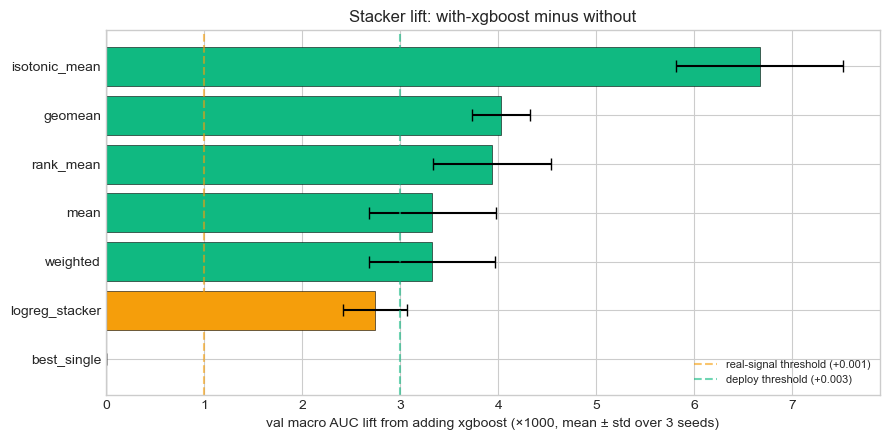

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
summary_plot = summary.sort_values('lift_mean')
colors = ['#dc2626' if v == 'noise' else '#f59e0b' if v == 'REAL SIGNAL' else '#10b981'
          for v in summary_plot['verdict']]
ax.barh(summary_plot.index, summary_plot['lift_mean'] * 1000,
        xerr=summary_plot['lift_std'] * 1000,
        color=colors, edgecolor='black', linewidth=0.4, capsize=4)
ax.axvline(1.0, linestyle='--', color='#f59e0b', alpha=0.6, label='real-signal threshold (+0.001)')
ax.axvline(3.0, linestyle='--', color='#10b981', alpha=0.6, label='deploy threshold (+0.003)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'val macro AUC lift from adding {CLASSICAL_MODEL} (×1000, mean ± std over 3 seeds)')
ax.set_title(f'Stacker lift: with-{CLASSICAL_MODEL} minus without')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


## 7 — How to read the result

**If `rank_mean` shows the biggest lift**: ship rank-mean as your blend in the submission notebook. It's three 
lines of code and benefits from the classical model's diversity without any tuning risk.

**If `logreg_stacker` wins by a clear margin** (≥0.001 over `rank_mean`): ship the per-class LR stacker. Five 
coefficients per species, trivial to serialize, and adapts the blend per species — noisy-on-some-species classical 
models get down-weighted exactly where they hurt.

**If `weighted` assigns the classical model > 0.10**: empirical confirmation that the diversity argument is real — 
the optimizer voluntarily gave meaningful weight to a 7-9-AUC-point-weaker model.

**If all methods come back `noise`**: the gap was simply too large for the low correlation to overcome at this 
scale. Don't add the classical model. Go to notebook 14.

**Try the other classical model.** If the primary (XGBoost) shows `noise` but you want to be thorough before 
concluding, set `CLASSICAL_MODEL = 'lightgbm'` at the top of section 0 and re-run sections 2-6. LightGBM has a 
wider AUC gap but also slightly different errors — not impossible that it lifts a method XGBoost doesn't.

**Caveat on scope.** Fold-0 only (the classical OOF didn't cover all 5 folds). Single-fold val AUC is noisier than 
full 5-fold OOF. Any lift you see should be confirmed on the full 5-fold setup before being shipped to LB. The 
3-seed averaging here helps with split noise but doesn't help with per-fold variance.
